# Lab 03 - Extended Exercises on Model Evaluation
## Predicting student performance

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, KFold, cross_validate, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler,  OneHotEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, auc
from sklearn.utils import resample

# Data directory
DATA_DIR = "./../../data/"

In [2]:
import requests

exec(requests.get("https://courdier.pythonanywhere.com/get-send-code").content)

npt_config = {
    'session_name': 'lab-05',
    'session_owner': 'mlbd',
    'sender_name': input("Your name: "),
}

Your name:  P


## Introduction
The data has already been cleaned and it comes from 29 students in 3 different groups in a course of 26 weeks.

You already used this data in week 03. 

In this lab you will explore different models to predict the quiz grade. 

In [2]:
# Load data
df= pd.read_csv(f'{DATA_DIR}grades_in_time.csv.gz')
df.head()

,student,week,studying_hours,group,quiz_grade
0,0,0,39.9,3,6.1
1,0,1,32.4,3,7.0
2,0,2,17.5,3,6.9
3,0,3,16.0,3,7.0
4,0,4,15.9,3,7.2


In [3]:
df.describe(include='all')

,student,week,studying_hours,group,quiz_grade
count,810.000000,810.000000,810.000000,810.000000,810.000000
mean,14.500000,13.000000,10.050617,1.933333,6.931975
std,8.660789,7.793693,8.270041,0.772199,1.336888
min,0.000000,0.000000,1.000000,1.000000,1.200000
25%,7.000000,6.000000,5.700000,1.000000,6.400000
50%,14.500000,13.000000,7.800000,2.000000,7.200000
75%,22.000000,20.000000,11.100000,3.000000,7.800000
max,29.000000,26.000000,64.000000,3.000000,10.100000


# 

# Task 1: Predict the quiz grade using the studying hours and the group.
----------
### 1.1 Split the data. 80% to train and the rest to test. 


In [4]:
X = df[['studying_hours', 'group']]
y = df['quiz_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

### 1.2 Preprocess the data
Recall that group is a categorical feature.

Hint: Use ColumnTransformer.

In [5]:
preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', drop = 'first'), ['group']),
    ('numerical', MinMaxScaler(),['studying_hours'])
])

preprocessor.fit_transform(X_train)

array([[0.        , 0.        , 0.07482993],
       [0.        , 1.        , 0.13945578],
       [0.        , 0.        , 0.11904762],
       ...,
       [1.        , 0.        , 0.08333333],
       [0.        , 0.        , 0.30782313],
       [0.        , 1.        , 0.16156463]], shape=(648, 3))

### 1.3 Create a pipeline (including the preprocessing steps) to predict the quiz grade using the studying hours and the group.

1. Use the model ElasticNet for the regression task.
2. Calculate the mean sqaured error of the prediction. 


Hint: Integrate the ColumnTransformer as a pipeline step

In [6]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
error = round(mean_squared_error(y_test, y_pred),3)
print(f"Mean Squared Error = {error}")

Mean Squared Error = 1.582


### 1.4 Compute the cross validation score

In [7]:
# Fit a pipeline with transformers and an estimator to the training data
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet())
])

(-1)*np.mean(cross_val_score(pipe, X, y, cv = 5, scoring = 'neg_mean_squared_error'))

np.float64(1.8575008478128328)

### 1.5 Does the score in 1.3 differ from the score in 1.4? Why? 

Answer = 1.3 is one fold and 1.4 is the average of multiple folds.

### 1.6 What is wrong with data split?
Answer: In some instances, we are using the data from future weeks to predict the grade in prior weeks. This is wrong as it doesn't reflect the reality at practice.

In [8]:
df.iloc[X_test.index][['week','student']]

,week,student
613,19,22
202,13,7
55,1,2
478,19,17
27,0,1
...,...,...
749,20,27
71,17,2
49,22,1
416,11,15


# Model Selection

Of course, when training ML models, we want to tune their hyperparameters in order to optimize the performance. In order to tune the hyperparameters of a model, we need to do further splits of our data set. To do so, we can freely combine the approaches presented in the model assessment section. In the following, we present a few ideas.

In [10]:
# Loading the data

# Parse the aggregated student data frame.
# This data is from an EPFL Linear Algebra flipped classroom. df_lq is aggregated features for the last week of student performance.
# ts represents the students' time series features.

df_lq = pd.read_csv('{}/aggregated_extended_fc.csv'.format(DATA_DIR))
ts = pd.read_csv('{}/time_series_extended_fc.csv'.format(DATA_DIR))

def remove_inactive_students(df, ts):
    """
    Filter the students (removing the ones that are inactive) to proceed with analysis on students who have participated during the entire class.
    Inputs: df, ts
    Outputs: filtered df, ts
    """
    # Fill all NaNs with strings to make them easier to process
    df = df.fillna('NaN')
    
    # Find all users weeks with 0 clicks on weekends and 0 clicks on weekdays during the first few weeks of the semester
    df_first = ts[ts.week < 5]
    rows = np.where(np.logical_and(df_first.ch_total_clicks_weekend==0, df_first.ch_total_clicks_weekday==0).to_numpy())[0]
    df_zero = df_first.iloc[rows, :]
    dropusers = np.unique(df_zero.user)

    # Drop users with no activity
    ts = ts[~ts.user.isin(dropusers)]
    df = df[~df.user.isin(dropusers)]
    return df, ts

df_lq, ts = remove_inactive_students(df_lq, ts)

# The `compute_scores` function computes the performance of classifiers with accuracy + AUC. We will use this evaluation function for all our experiments.
def compute_scores(clf, X_train, y_train, X_test, y_test, roundnum=3, report=False):
    """
    Train clf (binary classification) model on X_train and y_train, predict on X_test. Evaluate predictions against ground truth y_test.
    Inputs: clf, training set (X_train, y_train), test set (X_test, y_test)
    Inputs (optional): roundnum (number of digits for rounding metrics), report (print scores)
    Outputs: accuracy, AUC
    """
    # Fit the clf predictor (passed in as an argument)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # Calculate accuracy score
    accuracy = accuracy_score(y_test, y_pred)

    # Calculate roc AUC score
    AUC = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
    
    # Print classification results
    if report:
        print(classification_report(y_test, y_pred))

    return round(accuracy, roundnum), round(AUC, roundnum)

# We compute the pass/fail label of the students in the dataframe to use for the experiments. We will use the aggregated dataframe (df_lq) for all our experiments. If students have a grade higher than or equal to 4, they have passed the class.
df_lq['passed'] = (df_lq.grade >= 4).astype(int)

# Filter out demographic features
features = [x for x in df_lq.columns if x not in ['user', 'week', 'grade', 'gender', 'category', 'year', 'passed']]

# Only keep behavioral features in X.
X = df_lq[features]

# Our binary indicator variable is based on our evaluation criteria: pass/fail.
y = df_lq['passed']

### Example 1: Train-Test-Validation Split

In the first example we use a train-test setting to perform the outer split (model assessment) as well as the inner split (model selection). We hold out 20% of the data for testing and 10% of the data for validation (for hyperparameter tuning).

In [17]:
# Select the test set as 20% of the initial data set
X_1, X_test, y_1, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Select the training set as 70% of the initial dataset
# Select the validation set at 10% of the initial dataset (we use 1/8 here because we've already split the set once)
X_train, X_val, y_train, y_val = train_test_split(X_1, y_1, test_size=1/8, random_state=42, stratify=y_1)

# We compute a grid search across the following parameter space
parameters = {
    'n_estimators': [20, 50, 100],
    'criterion': ['entropy', 'gini'],
    'max_depth': np.arange(3, 9),
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 3, 5],
}

params_grid = ParameterGrid(parameters)

# For each combination of candidate parameters, fit a classifier on the training set and evaluate it on the validation set
results = [[params, compute_scores(RandomForestClassifier(random_state=42, **params), 
                                   X_train, y_train, X_val, y_val)] for params in params_grid]

# Sort candidate parameters according to their accuracy
results = sorted(results, key=lambda x: x[1][0], reverse=True)

# Obtain the best parameters
best_params = results[0][0]
best_params

{'criterion': 'gini',
 'max_depth': np.int64(4),
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 50}

In [18]:
# Train and evaluate a model based on the best parameter settings
clf = RandomForestClassifier(random_state=42, **best_params)
accuracy, AUC = compute_scores(clf, X_1, y_1, X_test, y_test)

print(f'Accuracy for train-validation-test setting: {accuracy}')
print(f'AUC for train-validation-test setting: {AUC}')

Accuracy for train-validation-test setting: 0.681
AUC for train-validation-test setting: 0.739


### Example 2: Nested 10-Fold Cross Validation

We use a 10-fold cross validation to perform the outer split (model assessment) as well as the inner split (model selection), leading to a **nested** 10-fold cross validation.

In [19]:
# We compute a grid search across the following parameter space
parameters = {
    'n_estimators': [20, 50, 100],
    'criterion': ['entropy', 'gini'],
    'max_depth': np.arange(3, 7),
    'min_samples_split': [2],
    'min_samples_leaf': [1],
}

In [20]:
# This cell takes ~3 minutes to run

# Inner cross validation loop
clf = GridSearchCV(RandomForestClassifier(random_state=42), parameters, cv=10)

# Outer cross validation loop
scores_nested_cv = cross_validate(clf, X, y, cv=3, scoring=['accuracy', 'roc_auc'])

In [21]:
print(f'Mean accuracy with nested cross-validation: {scores_nested_cv["test_accuracy"].mean():.3f}')
print(f'Mean AUC with nested cross-validation: {scores_nested_cv["test_roc_auc"].mean():.3f}')

Mean accuracy with nested cross-validation: 0.692
Mean AUC with nested cross-validation: 0.677


### Example 3: Cross Validation with Bootstrap

We perform cross validation on the bootstrap data set from before to tune the hyperparameters.

In [22]:
# We compute a grid search across the following parameter space
parameters = {
    'n_estimators': [20, 50],
    'criterion': ['gini'],
    'max_depth': np.arange(3, 5),
    'min_samples_split': [2],
    'min_samples_leaf': [1],
}

In [23]:
df_size = len(df_lq)
B = 100

# Generate B samples with replacement
samples = [resample(X, y, replace=True, n_samples=df_size) for b in range(B)]
# Train a random forest classifier for each sample, cross-validating to find the best parameters
clfs = [GridSearchCV(RandomForestClassifier(random_state=42), parameters, cv=3).fit(X_b, y_b) for X_b, y_b in samples]

In [24]:
# Calculate the predictions for each bootstrap sample (b in range(B)).
# Compare predictions against the ground truth (y.loc[[user]]). 
# Take the mean of predictions for each student (over on the number of times they were predicted).
# Takes ~2 mins
accuracies_bootstrap = [np.mean([clfs[b].predict(X.loc[[user]]) == y.loc[[user]] for b in range(B) if user not in samples[b][0].index])
                        for user in df_lq.index]

In [25]:
# Take the mean of predictions across all students.
bootstrap_err = np.mean(accuracies_bootstrap)
bootstrap_err

np.float64(0.6745677096048838)

In [26]:
# Calculate the training error for each bootstrapped model, then average across bootstraps.
training_err_bootstrap = [clfs[b].score(samples[b][0], samples[b][1]) for b in range(B)]
training_err = np.mean(training_err_bootstrap)
training_err

np.float64(0.9191880341880343)

In [27]:
accuracy_632 = 0.632 * bootstrap_err + 0.368 * training_err
print(f'Mean accuracy with .632 leave-one-out bootstrapping: {accuracy_632:.3f}')

Mean accuracy with .632 leave-one-out bootstrapping: 0.765


### Example 4: Train-Test (Outer Loop) + 10-Fold Cross Validation (Inner Loop)

We perform a train-test outer split and use 10-fold cross validation on the inner split to tune the hyperparameters.

In [28]:
# Create outer loop with stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
# We compute a grid search across the following parameter space
parameters = {
    'n_estimators': [20, 50, 100],
    'criterion': ['entropy', 'gini'],
    'max_depth': np.arange(3, 7),
    'min_samples_split': [2],
    'min_samples_leaf': [1],
}

In [30]:
# Train model on inner loop with grid-search 10-fold cross validation
clf = GridSearchCV(RandomForestClassifier(random_state=42), parameters, cv=10)
accuracy, AUC = compute_scores(clf, X_train, y_train, X_test, y_test)

In [31]:
clf.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(3),
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

In [32]:
print(f'Accuracy for train-test splitting + cross-validation: {accuracy:.3f}')
print(f'AUC for train-test splitting + cross-validation: {AUC:.3f}')

Accuracy for train-test splitting + cross-validation: 0.638
AUC for train-test splitting + cross-validation: 0.724


## Reporting Results

When reporting results, it is good practice to report the uncertainty of the prediction. In the following, we provide examples on how to assess the uncertainty of the predictions.

### Cross Validation

When performing cross validation we can compute the standard deviation (or standard error) of the performance metric across folds. We use a nested cross validated (10-fold, stratified) for the Random Forest model and tune the hyperparameters (example 2b above). 

Using the results from [Example 2](#Example-2:-Correct), we recover the accuracy and the AUC over all 10 folds

In [33]:
scores_nested_cv

{'fit_time': array([14.44338393, 14.40573025, 14.51075983]),
 'score_time': array([0.01390696, 0.00580239, 0.01399565]),
 'test_accuracy': array([0.71794872, 0.66666667, 0.69230769]),
 'test_roc_auc': array([0.70418668, 0.67467399, 0.65271105])}

In [34]:
accuracies_nested_cv = scores_nested_cv['test_accuracy']
AUC_nested_cv = scores_nested_cv['test_roc_auc']

# Compute standard deviation of Accuracy and AUC
print(f'Accuracy standard deviation with nested cross-validation: {accuracies_nested_cv.std():.3f}')
print(f'AUC standard deviation with nested cross-validation: {AUC_nested_cv.std():.3f}')

Accuracy standard deviation with nested cross-validation: 0.021
AUC standard deviation with nested cross-validation: 0.021


In [35]:
# Group scores in a DataFrame for visualization with error bars
cv_df = pd.DataFrame({'Accuracy': accuracies_nested_cv, 'AUC': AUC_nested_cv, 'Method': ['nested cv']*3})

### Bootstrapping

When performing bootstrapping, we can also compute uncertainty, because we get multiple predictions for one sample.

Again, using the results from [Example 3](#Example-3), we recover the accuracy for each sample. To assess the uncertainty of the .632 accuracy, we need to sum them beforehand with the weighted training error.

In [36]:
# Determine accuracy 632 across bootstrap and training error
accuracies_632 = 0.632 * np.array(accuracies_bootstrap) + 0.368 * training_err

In [37]:
print(f'Accuracy standard deviation with .632 bootstrapping: {accuracies_632.std():.3f}')

Accuracy standard deviation with .632 bootstrapping: 0.231


In [38]:
# AUC is None here (as discussed earlier in the notebook) because the ROC curve cannot be computed for leave-one-out bootstrap.
# Group scores in a DataFrame for visualization with error bars.
bootstrap_df = pd.DataFrame({'Accuracy': accuracies_632, 'AUC': [None] * df_size, 'Method': ['.632 bootstrap'] * df_size})

### Train-Test + Bootstrap

Instead of using a full bootstrap, we can do a train-test split first and train the model on the training data. We can then perfrom bootstrapping on the test set and generate a 100 bootstrapped test sets. This enables us to examine the uncertainty for this setting. We use a similar setting to [Example 4](#Example-4).

In [39]:
# Create outer loop with train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# Fit a Random Forest classifier using a grid search (via cross validation) on the training data
clf = GridSearchCV(RandomForestClassifier(random_state=42), parameters, cv=3)
clf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini'], 'max_depth': array([3, 4, 5, 6]), 'min_samples_leaf': [1], 'min_samples_split': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [41]:
# Since we're using the bootstrap over the test set, it's important to resample the same size (test_size), randomly, with replacement (replace=True)
test_size = len(X_test)
B = 100

# Generate B samples with replacement
samples = [resample(X_test, y_test, replace=True, n_samples=test_size) for b in range(B)]

In [42]:
# Compute the accuracy and the AUC for each bootstrapped sample
accuracies_split_bootstrap = [clf.score(X_b, y_b) for X_b, y_b in samples]
AUC_split_bootstrap = [roc_auc_score(y_b, clf.predict_proba(X_b)[:, 1]) for X_b, y_b in samples]

In [43]:
# Compute the standard deviation of the accuracies and AUC scores across bootstraps
print(f'Accuracy standard deviation with split + bootstrapping: {np.std(accuracies_split_bootstrap):.3f}')
print(f'AUC standard deviation with split + bootstrapping: {np.std(AUC_split_bootstrap):.3f}')

Accuracy standard deviation with split + bootstrapping: 0.068
AUC standard deviation with split + bootstrapping: 0.073


In [44]:
# Group scores in a DataFrame for visualization with error bars
split_bootstrap_df = pd.DataFrame({'Accuracy': accuracies_split_bootstrap, 'AUC': AUC_split_bootstrap, 'Method': ['split_bootstrap'] * B})

### Visualizing uncertainty

In [45]:
df = pd.concat([cv_df.dropna(axis=1, how='all'), 
                bootstrap_df.dropna(axis=1, how='all'), 
                split_bootstrap_df.dropna(axis=1, how='all')])
df.head()

,Accuracy,AUC,Method
0,0.717949,0.704187,nested cv
1,0.666667,0.674674,nested cv
2,0.692308,0.652711,nested cv
0,0.677383,NaN,.632 bootstrap
1,0.898443,NaN,.632 bootstrap


Here, the error bars represent the 95% confidence intervals across our three experiments (cross validation, bootstrap, train-test split + bootrap).

<Axes: xlabel='Method', ylabel='Accuracy'>

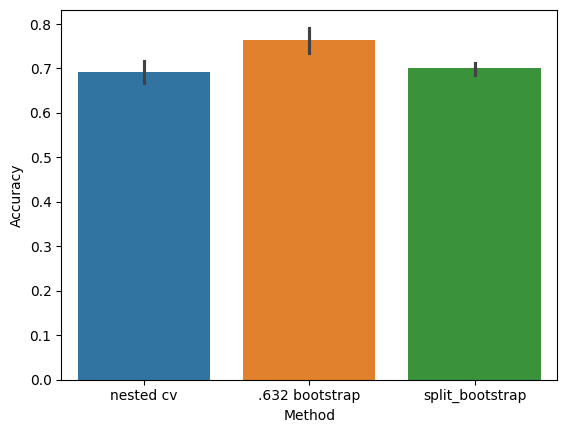

In [46]:
sns.barplot(x='Method', y='Accuracy', data=df, errorbar='ci', hue='Method')

<Axes: xlabel='Method', ylabel='AUC'>

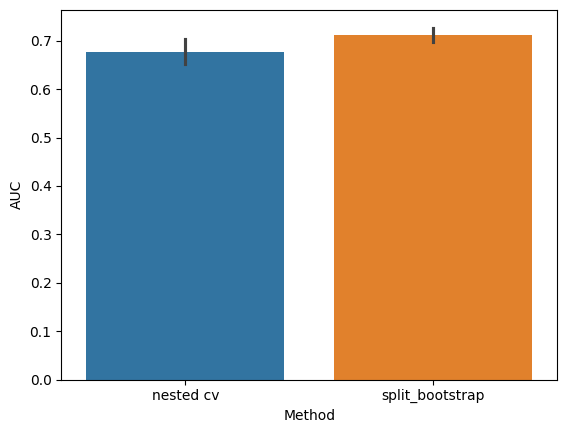

In [47]:
sns.barplot(x='Method', y='AUC', data=df[df.Method != '.632 bootstrap'], errorbar='ci', hue='Method')